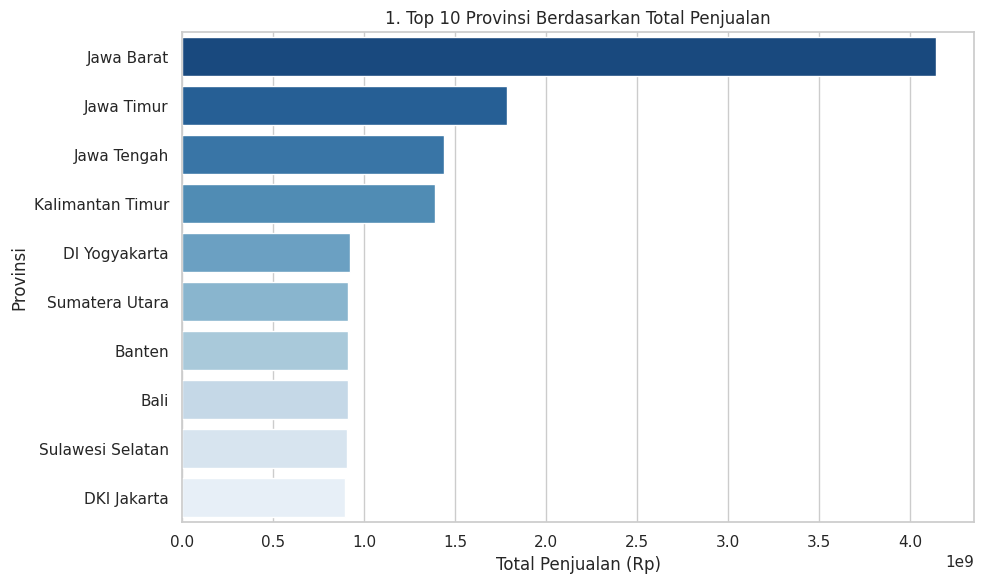

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

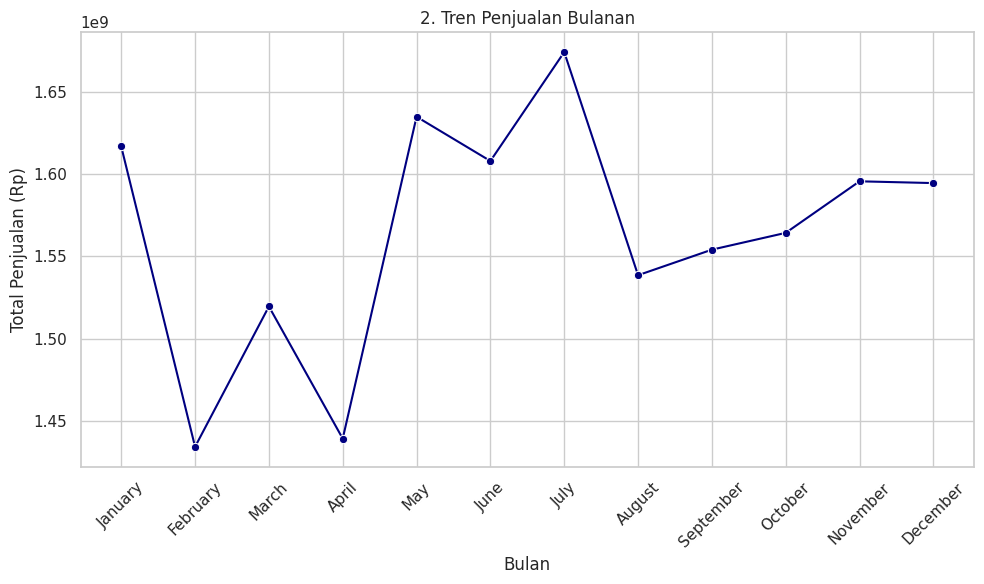

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

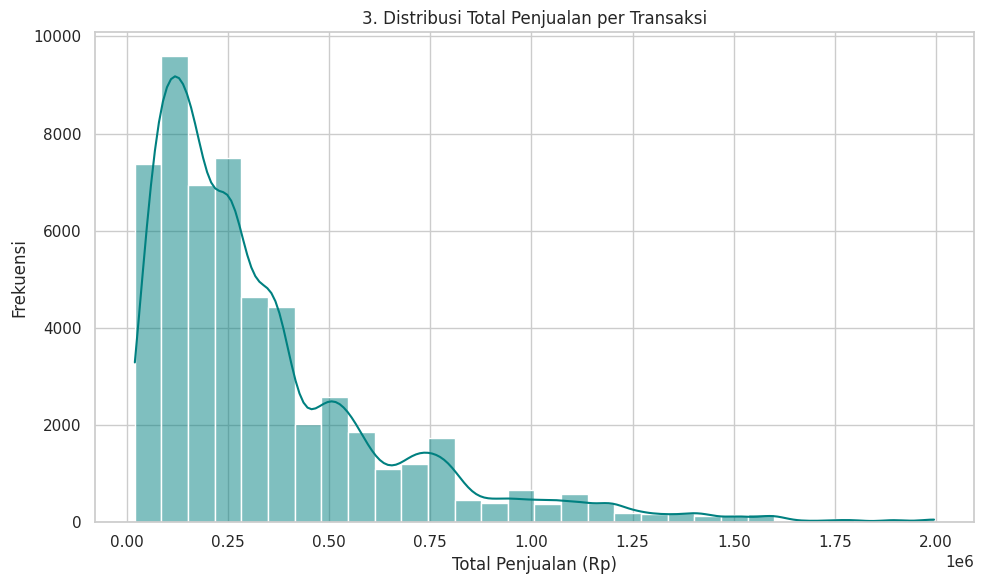

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

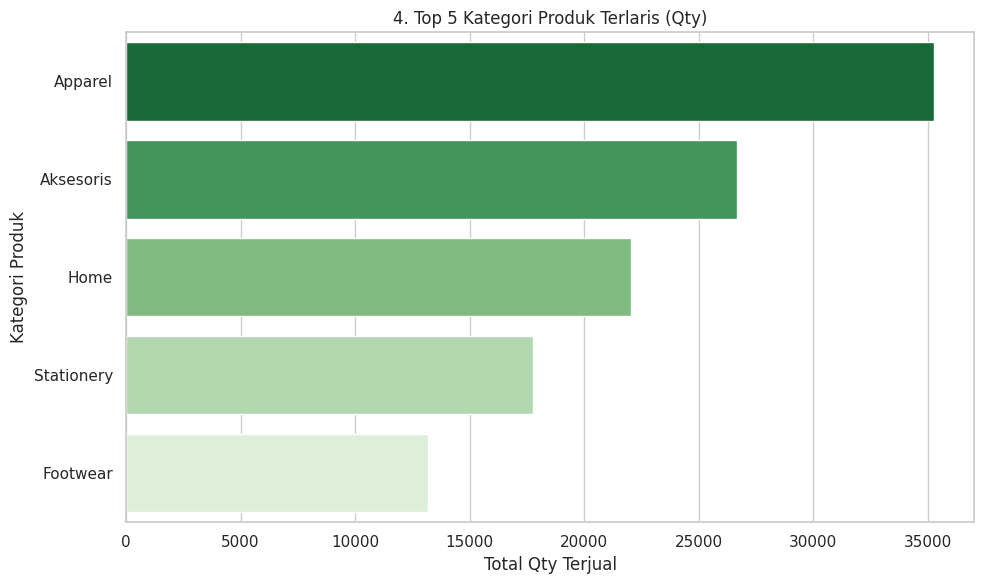

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

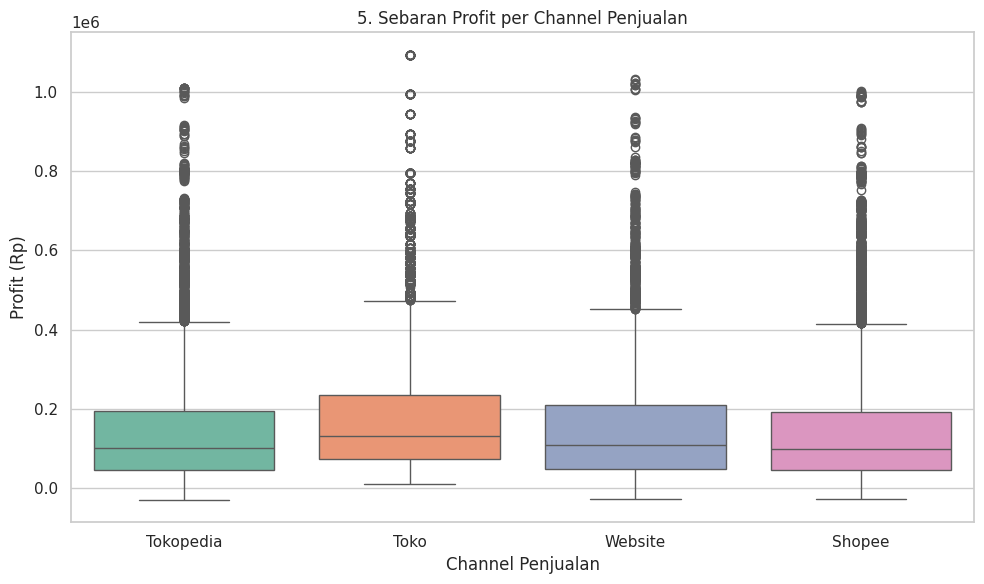

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

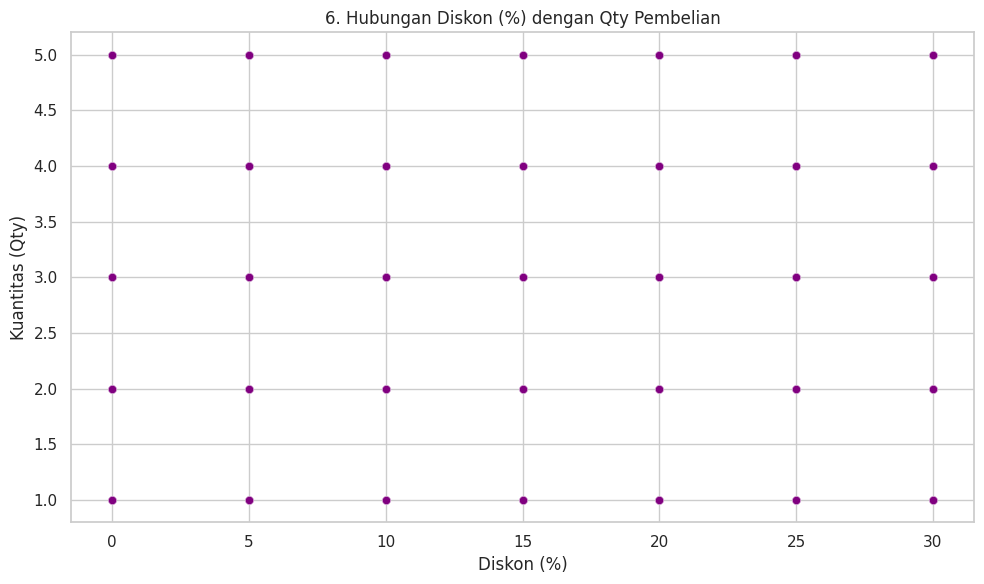

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

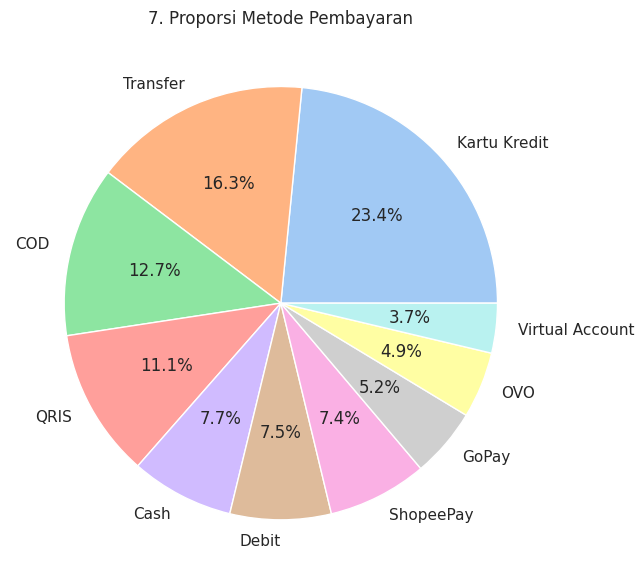

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

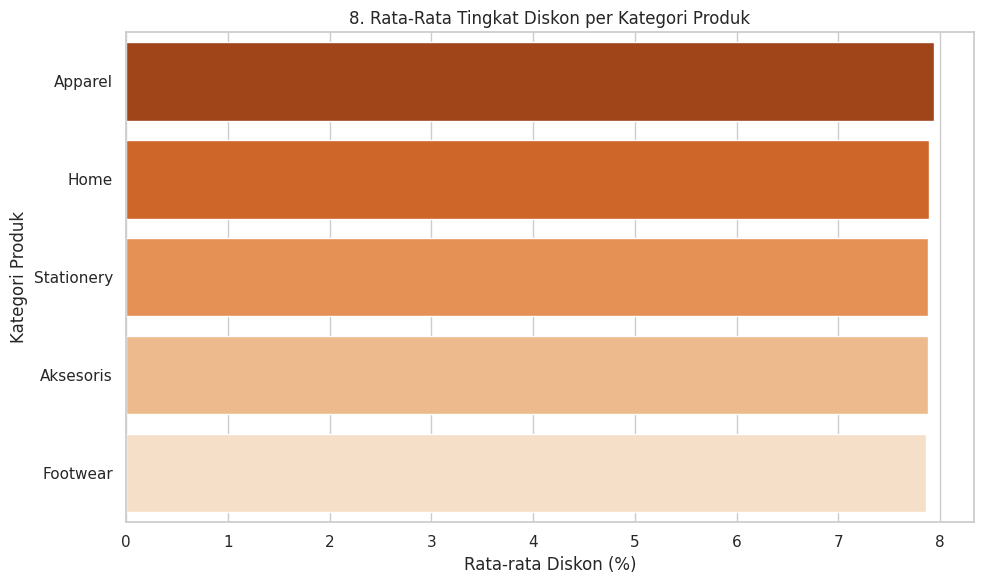

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

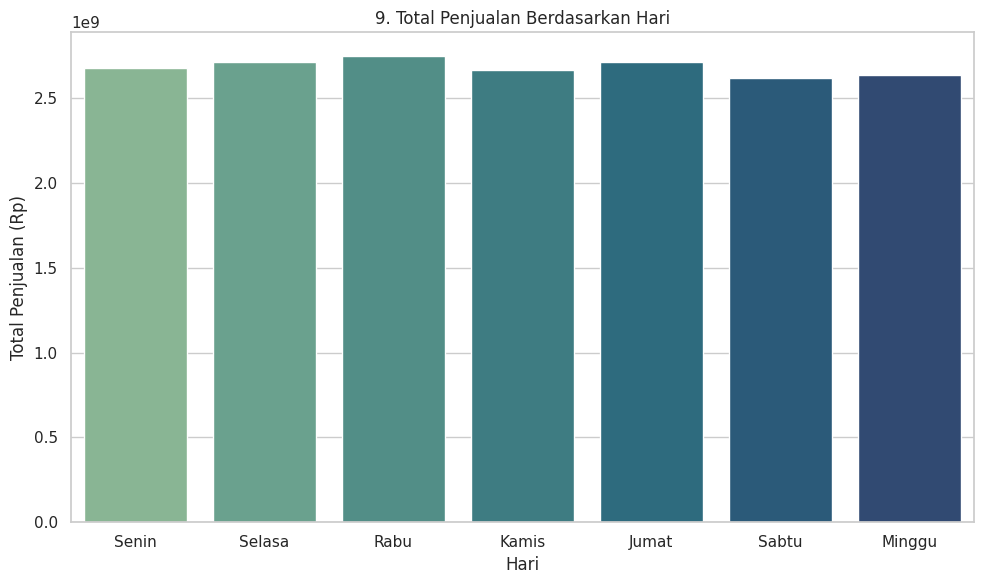

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

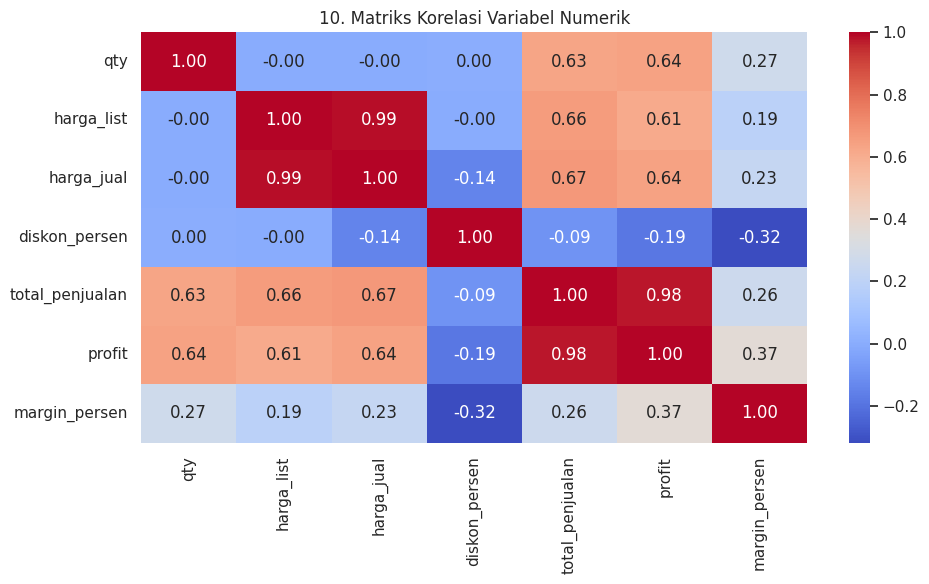

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.colab import files

# Atur gaya tampilan
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset
df = pd.read_csv('retail_indonesia_55k_cleaned.csv')
df['tanggal_transaksi'] = pd.to_datetime(df['tanggal_transaksi'])

# 1. Total Penjualan per Provinsi (Top 10)
plt.figure()
top_prov = (
    df.groupby('provinsi')['total_penjualan'].sum().nlargest(10).reset_index()
)
sns.barplot(
    data=top_prov,
    x='total_penjualan',
    y='provinsi',
    hue='provinsi',
    legend=False,
    palette='Blues_r',
)
plt.title('1. Top 10 Provinsi Berdasarkan Total Penjualan')
plt.xlabel('Total Penjualan (Rp)')
plt.ylabel('Provinsi')
plt.tight_layout()

plt.savefig('01.total_penjualan.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('01.total_penjualan.png')

# 2. Tren Penjualan Bulanan
monthly_sales = (
    df.groupby(['tahun', 'bulan_num', 'bulan'])['total_penjualan']
    .sum()
    .reset_index()
    .sort_values(by=['tahun', 'bulan_num'])
)
plt.figure()
sns.lineplot(
    data=monthly_sales,
    x='bulan',
    y='total_penjualan',
    marker='o',
    color='navy',
)
plt.title('2. Tren Penjualan Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Total Penjualan (Rp)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('02.tren_penjualan.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('02.tren_penjualan.png')

# 3. Distribusi Total Penjualan per Transaksi (Histogram)
plt.figure()
sns.histplot(df['total_penjualan'], bins=30, kde=True, color='teal')
plt.title('3. Distribusi Total Penjualan per Transaksi')
plt.xlabel('Total Penjualan (Rp)')
plt.ylabel('Frekuensi')
plt.tight_layout()

plt.savefig('03.distribusi_per_transaksi.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('03.distribusi_per_transaksi.png')

# 4. Top 5 Kategori Produk Terlaris (Kuantitas / Qty)
top_kategori = (
    df.groupby('kategori')['qty'].sum().nlargest(5).reset_index()
)
plt.figure()
sns.barplot(
    data=top_kategori,
    x='qty',
    y='kategori',
    hue='kategori',
    legend=False,
    palette='Greens_r',
)
plt.title('4. Top 5 Kategori Produk Terlaris (Qty)')
plt.xlabel('Total Qty Terjual')
plt.ylabel('Kategori Produk')
plt.tight_layout()

plt.savefig('04.top_5_kategori_produk_terlaris.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('04.top_5_kategori_produk_terlaris.png')

# 5. Sebaran Profit per Channel Penjualan (Boxplot)
plt.figure()
sns.boxplot(
    data=df,
    x='channel_penjualan',
    y='profit',
    hue='channel_penjualan',
    legend=False,
    palette='Set2',
)
plt.title('5. Sebaran Profit per Channel Penjualan')
plt.xlabel('Channel Penjualan')
plt.ylabel('Profit (Rp)')
plt.tight_layout()

plt.savefig('05.Sebaran_profit_per_channel_penjualan.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('05.Sebaran_profit_per_channel_penjualan.png')

# 6. Hubungan Persentase Diskon dengan Qty Pembelian (Scatter Plot)
plt.figure()
sns.scatterplot(
    data=df, x='diskon_persen', y='qty', alpha=0.3, color='purple'
)
plt.title('6. Hubungan Diskon (%) dengan Qty Pembelian')
plt.xlabel('Diskon (%)')
plt.ylabel('Kuantitas (Qty)')
plt.tight_layout()

plt.savefig('06.Hubungan_Persentase_Diskon_dengan_Qty_Pembelian.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('06.Hubungan_Persentase_Diskon_dengan_Qty_Pembelian.png')

# 7. Proporsi Metode Pembayaran (Pie Chart)
plt.figure()
payment_counts = df['metode_pembayaran'].value_counts()
plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
)
plt.title('7. Proporsi Metode Pembayaran')
plt.tight_layout()

plt.savefig('07.Proporsi_Metode_Pembayaran.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('07.Proporsi_Metode_Pembayaran.png')

# 8. Rata-Rata Diskon per Kategori Produk
plt.figure()
avg_diskon = (
    df.groupby('kategori')['diskon_persen']
    .mean()
    .reset_index()
    .sort_values(by='diskon_persen', ascending=False)
)
sns.barplot(
    data=avg_diskon,
    x='diskon_persen',
    y='kategori',
    hue='kategori',
    legend=False,
    palette='Oranges_r',
)
plt.title('8. Rata-Rata Tingkat Diskon per Kategori Produk')
plt.xlabel('Rata-rata Diskon (%)')
plt.ylabel('Kategori Produk')
plt.tight_layout()

plt.savefig('08.Rata_Rata_Diskon_per_Kategori_Produk.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('08.Rata_Rata_Diskon_per_Kategori_Produk.png')

# 9. Total Penjualan Berdasarkan Hari dalam Seminggu
hari_order = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
plt.figure()
sns.barplot(
    data=df,
    x='hari',
    y='total_penjualan',
    order=hari_order,
    estimator=sum,
    errorbar=None,
    hue='hari',
    legend=False,
    palette='crest',
)
plt.title('9. Total Penjualan Berdasarkan Hari')
plt.xlabel('Hari')
plt.ylabel('Total Penjualan (Rp)')
plt.tight_layout()

plt.savefig('09.Total_Penjualan_Berdasarkan_Hari.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('09.Total_Penjualan_Berdasarkan_Hari.png')

# 10. Matriks Korelasi Variabel Numerik (Heatmap)
plt.figure()
cols_num = [
    'qty',
    'harga_list',
    'harga_jual',
    'diskon_persen',
    'total_penjualan',
    'profit',
    'margin_persen',
]
sns.heatmap(df[cols_num].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('10. Matriks Korelasi Variabel Numerik')
plt.tight_layout()

plt.savefig('10.Matriks_Korelasi_Variabel_Numerik.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('10.Matriks_Korelasi_Variabel_Numerik.png')